# Lazy vs rich training dynamics

Left: `lazy_balance.json` (`init_block_scale = 5`). Right: `rich_balance.json` (`init_block_scale = 1`). Rows: real vs null frustration, loss, relative distance from the init.
The `distance` column in the json is the absolute L2 distance of the network edge weights, which scales with the init magnitude (the lazy run starts 5x larger, its OV product 25x); it is divided here by the init norm computed from the run's `train_config`, so the two panels share one y axis.
Formatted for a NeurIPS figure (5.5 in text width, Times, 8 pt). Writes `lazy_rich_balance.pdf` (use this in LaTeX) and `lazy_rich_balance.png` (preview).

Lazy: ||theta_0|| = 1053.5, final relative distance = 0.805
Rich: ||theta_0|| = 153.4, final relative distance = 1.664


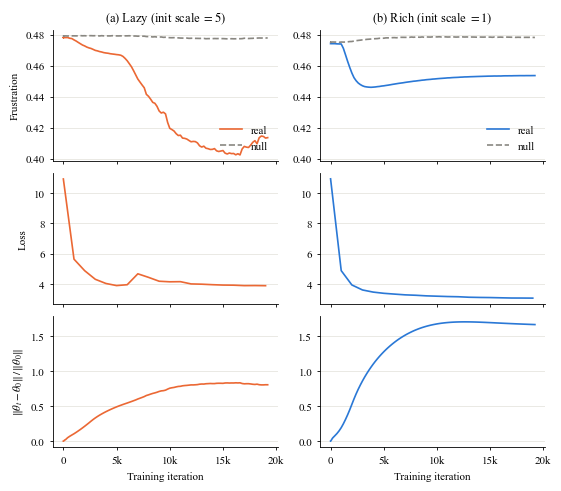

In [1]:
import json
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter

# NeurIPS: 5.5 in text width, Times body font, embedded TrueType (no Type 3) fonts in the PDF.
plt.rcParams.update({
    "font.family": "serif",
    "font.serif": ["Times New Roman", "Times", "STIXGeneral"],
    "mathtext.fontset": "stix",
    "font.size": 8,
    "axes.titlesize": 9,
    "axes.labelsize": 8,
    "xtick.labelsize": 8,
    "ytick.labelsize": 8,
    "legend.fontsize": 8,
    "axes.linewidth": 0.6,
    "xtick.major.width": 0.6,
    "ytick.major.width": 0.6,
    "xtick.major.size": 2.5,
    "ytick.major.size": 2.5,
    "lines.linewidth": 1.2,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "pdf.fonttype": 42,
    "ps.fonttype": 42,
})

RUNS = [  # (file, panel title, line colour)
    ("lazy_balance.json", "Lazy", "#eb6834"),
    ("rich_balance.json", "Rich", "#2a78d6"),
]
NULL_COLOR = "#898781"
OUT = Path("lazy_rich_balance")


def init_edge_norm(tc):
    """||vals0||: L2 norm of the network edge weights at init (T=1, no embeddings), from the run config.

    The edges are W1, W2 and the product WO@WV of every block (transformer_utils.network_construction);
    the identity / attention edges are constants and cancel in the distance. Every weight is
    N(0, std^2) times init_block_scale, and c_proj (WO, W2) additionally times the residual scale,
    so E||W||^2 = numel * var. Matches the norm of the actual seed-0 init to 4 digits.
    """
    d, L, std, s = tc["n_embd"], tc["n_layer"], tc["init_std"], tc["init_block_scale"]
    proj = tc["init_proj_scale"] * (1 / np.sqrt(2 * L) if tc["init_scale_residual"] else 1.0)
    v_in = (std * s) ** 2           # variance of a W1 / WV entry
    v_out = (std * s * proj) ** 2   # variance of a W2 / WO entry
    per_layer = 4 * d * d * v_in + 4 * d * d * v_out + d * d * (d * v_in * v_out)  # W1 + W2 + WO@WV
    return np.sqrt(L * per_layer)


fig, axes = plt.subplots(3, 2, figsize=(5.5, 4.8), sharex=True, constrained_layout=True)
for col, (fname, name, color) in enumerate(RUNS):
    d = json.load(open(fname))
    tc = d["train_config"]
    it = np.array(d["epoch"])  # training iterations (max_iters = 19200)
    ax_frust, ax_loss, ax_dist = axes[:, col]

    ax_frust.plot(it, d["r_frust"], color=color, label="real")
    ax_frust.plot(it, [v[0] for v in d["n_frust"]], color=NULL_COLOR, ls="--", label="null")
    ax_frust.legend(loc="lower right", frameon=False)
    ax_frust.set_title(rf"({'ab'[col]}) {name} (init scale $= {tc['init_block_scale']:g}$)")

    # loss is only re-evaluated every eval_interval iterations; snapshots in between repeat the stale value
    evaluated = it % tc["eval_interval"] == 0
    ax_loss.plot(it[evaluated], np.array(d["loss"])[evaluated], color=color)

    # the json stores the absolute L2 distance ||theta_t - theta_0|| over the edge weights, which
    # scales with the init magnitude; divide by ||theta_0|| so the two runs are comparable
    norm0 = init_edge_norm(tc)
    rel = np.array(d["distance"], dtype=float) / norm0
    print(f"{name}: ||theta_0|| = {norm0:.1f}, final relative distance = {rel[-1]:.3f}")
    ax_dist.plot(it, rel, color=color)
    ax_dist.set_xlabel("Training iteration")
    ax_dist.xaxis.set_major_formatter(FuncFormatter(lambda v, _: f"{v / 1000:g}k" if v else "0"))

# same y scale across the two runs in every row
for row in axes:
    row[0].sharey(row[1])
axes[0, 0].set_ylabel("Frustration")
axes[1, 0].set_ylabel("Loss")
axes[2, 0].set_ylabel(r"$\|\theta_t - \theta_0\| \, / \, \|\theta_0\|$")
for ax in axes.flat:
    ax.grid(axis="y", color="#e1e0d9", lw=0.5)

fig.savefig(OUT.with_suffix(".pdf"))
fig.savefig(OUT.with_suffix(".png"), dpi=300)
